In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import COASTLINE

In [88]:
def plot_spatial(lon, lat, data, cbar_label=None, title=None, cmap="bwr",
                  vmin=None, vmax=None, norm=None, extend="both", ax=None):
    # Using PlateCarree projection which is commonly used for lat/lon data.
    if ax is None:
        ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))  
    if vmin is not None:
        img = ax.contourf(lon, lat, data, np.linspace(vmin, vmax, 20), cmap=cmap, 
                      transform=ccrs.PlateCarree(), norm=norm, extend=extend)
    else:
        img = ax.contourf(lon, lat, data, 20, cmap=cmap, 
                        transform=ccrs.PlateCarree(), norm=norm, extend=extend)
    # plt.imshow(r2, cmap="bwr", vmin=0, vmax=1)
    # Draw and label gridlines
    # Add coastlines
    ax.add_feature(COASTLINE, linewidth=0.5, edgecolor='black')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                      color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False  # Don't display top x-axis labels
    gl.right_labels = False  # Don't display right y-axis labels
    cbar = plt.colorbar(img,shrink=0.3)
    if cbar_label is not None:
        cbar.set_label(cbar_label)
    if title is not None:
        plt.title(title)

In [86]:
def get_min_max_coords(mask, pad):
    min_x = np.min(np.where(mask)[0])
    max_x = np.max(np.where(mask)[0])
    min_y = np.min(np.where(mask)[1])
    max_y = np.max(np.where(mask)[1])
    # wid_x = math.ceil((max_x - min_x)/2)*2
    # wid_y = math.floor((max_y - min_y)/2)*2
    # return int(min_x-pad), int(min_x+wid_x+pad), \
    #     int(min_y-pad), int(min_y+wid_y+pad)
    return min_x-pad, max_x+pad, min_y-pad, max_y+pad
region_mask = np.load("../consts/pacific_region_mask.npy")
min_x, max_x, min_y, max_y = get_min_max_coords(region_mask, 2)
lon = np.linspace(0,357.5,144)
lat = np.linspace(-90,90,96)
print("Region window coordinates: ", lon[min_y], lon[max_y], lat[min_x], lat[max_x])
def plot_pacific(data, **kwargs):
#     full_data = np.zeros((96,144))
#     for i in range(96):
#         for j in range(144):
#             full_data[i,j] = None
#     full_data[min_x:max_x,min_y:max_y] = data
    plot_spatial(lon[min_y:max_y], lat[min_x:max_x], data, **kwargs)

Region window coordinates:  110.0 247.5 -27.473684210526322 27.473684210526315


In [3]:
data_path = "../offline_test/"
vae_only = data_path + "vae_only/"
ae_only = data_path + "ae_only/"
qtend_test = data_path + "qtend_test/"
qtend_lev_test = data_path + "qtend_lev_test/"

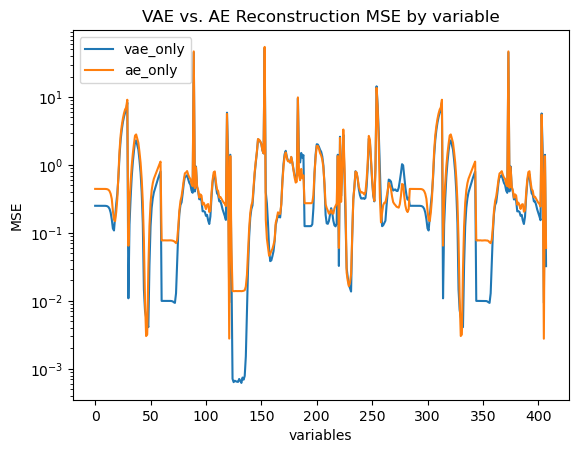

In [7]:
rec_lvl_fname = "offline_test_ae_avg_recmse_by_var.npy"
vae_lvl = np.load(vae_only + rec_lvl_fname)
ae_lvl = np.load(ae_only + rec_lvl_fname)
plt.plot(vae_lvl, label="vae_only")
plt.plot(ae_lvl, label="ae_only")
plt.title("VAE vs. AE Reconstruction MSE by variable")
plt.xlabel("variables")
plt.ylabel("MSE")
plt.yscale('log')
plt.legend()
plt.show()

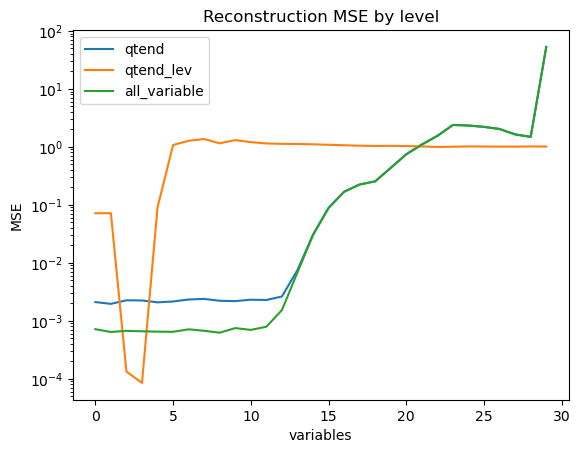

In [11]:
qtend_test_lvl = np.load(qtend_test + rec_lvl_fname)
qtend_lev_test_lvl = np.load(qtend_lev_test + rec_lvl_fname)
plt.plot(qtend_test_lvl, label="qtend")
plt.plot(qtend_lev_test_lvl, label="qtend_lev")
plt.plot(vae_lvl[124:154], label="all_variable")
plt.title("Reconstruction MSE by level")
plt.xlabel("variables")
plt.ylabel("MSE")
plt.yscale('log')
plt.legend()
plt.show()

In [171]:
def standardize(data):
    data = (data-data.mean())/data.std()
    return data

In [175]:
sample = "37621-37622"
lvl = 29

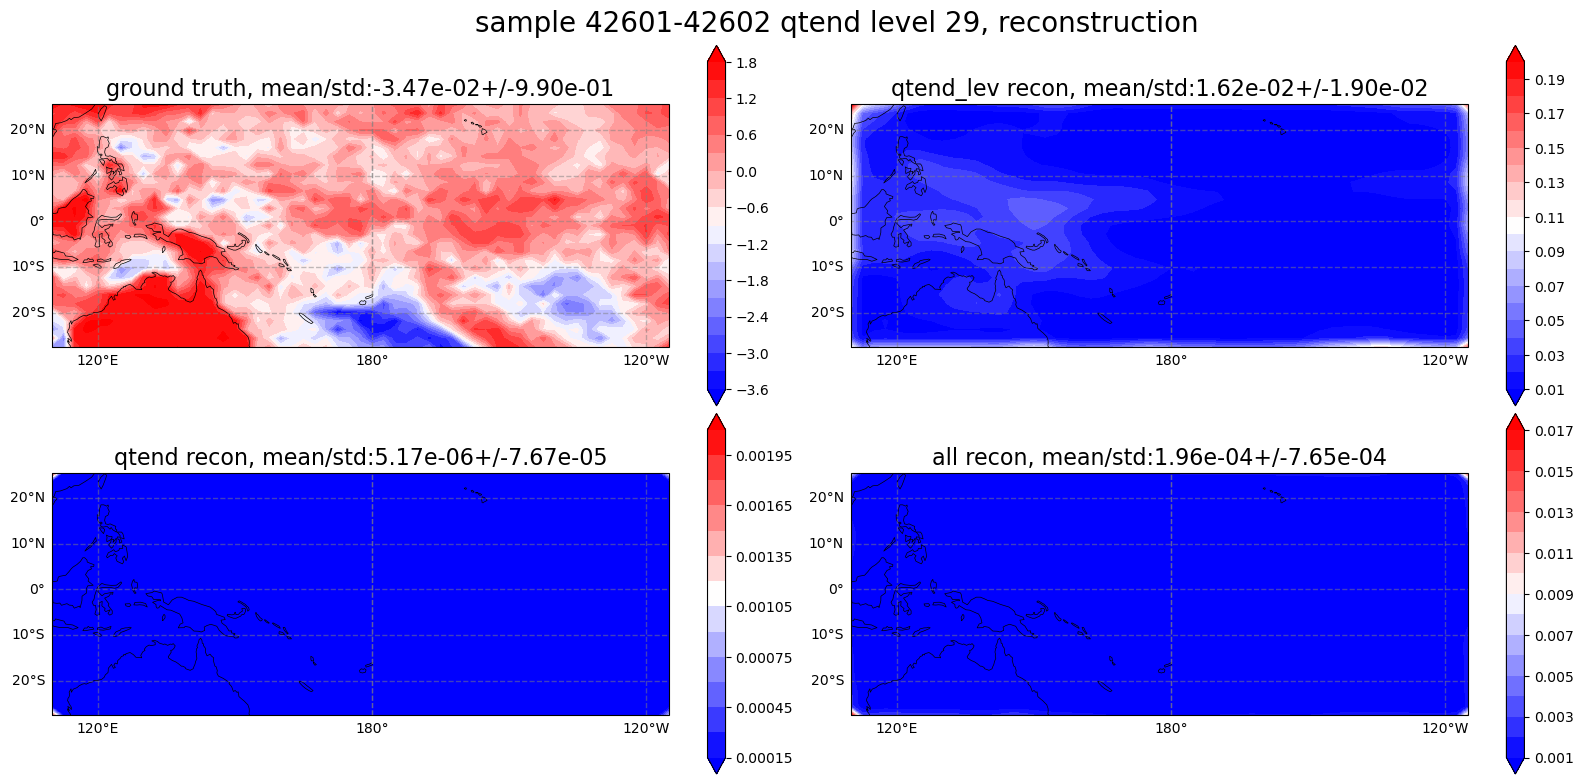

In [173]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")[0,lvl]
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl]
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154][0,lvl]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl]
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x,ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x.mean():.2e}+/-{qtend_lev_sample_x.std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec,ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec.mean():.2e}+/-{qtend_lev_sample_x_rec.std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec,ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec.mean():.2e}+/-{qtend_sample_x_rec.std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec,ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec.mean():.2e}+/-{all_sample_x_rec.std():.2e}",fontsize=16)
plt.show()

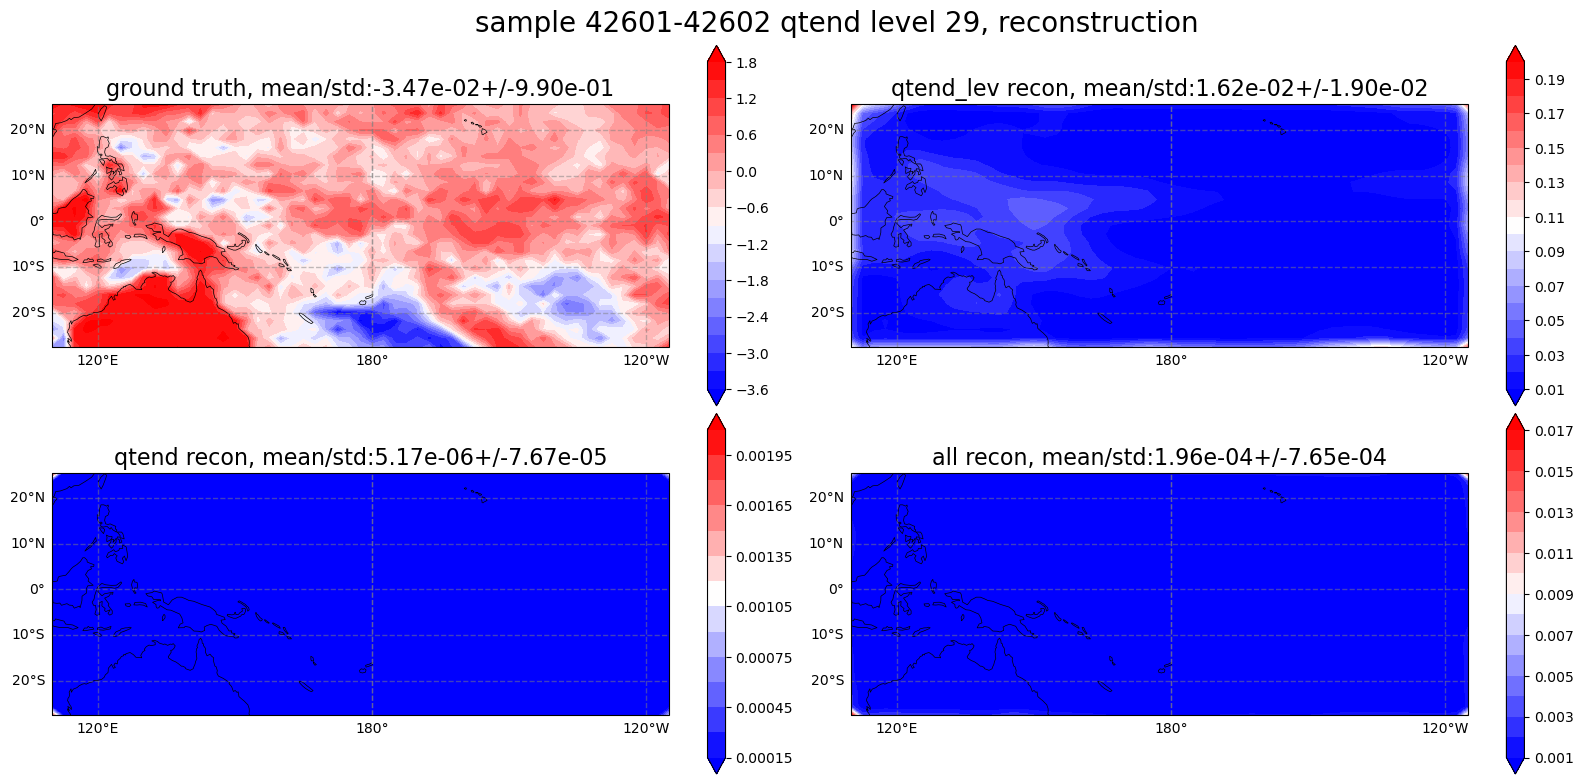

In [173]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")[0,lvl]
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_log_var.npy")[0,lvl]
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_log_var.npy")[:,124:154][0,lvl]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_log_var.npy")[0,lvl]
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x,ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x.mean():.2e}+/-{qtend_lev_sample_x.std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec,ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec.mean():.2e}+/-{qtend_lev_sample_x_rec.std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec,ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec.mean():.2e}+/-{qtend_sample_x_rec.std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec,ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec.mean():.2e}+/-{all_sample_x_rec.std():.2e}",fontsize=16)
plt.show()

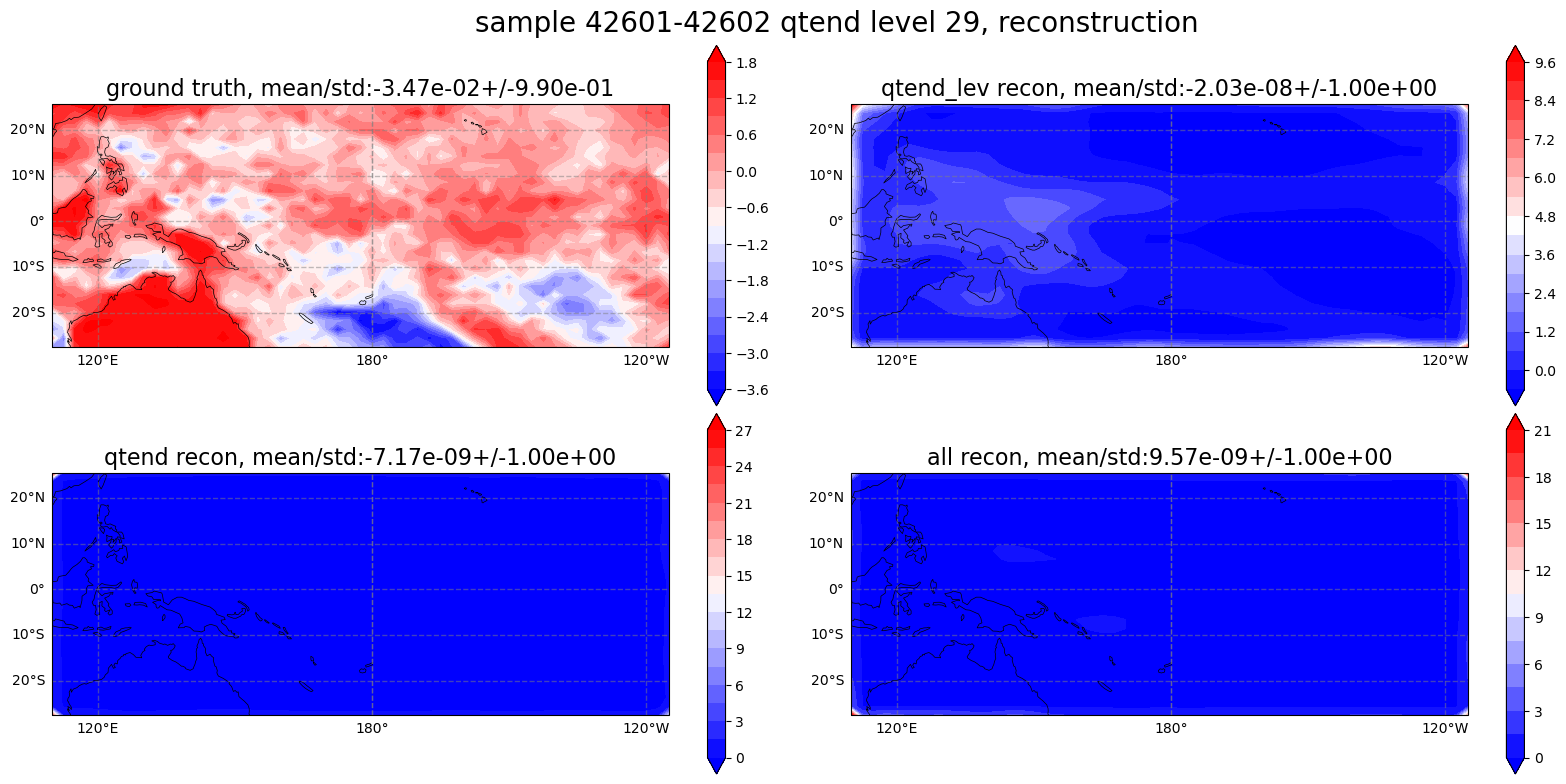

In [172]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")[0,lvl]
qtend_lev_sample_x_rec = standardize(np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl])
all_sample_x_rec = standardize(np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154][0,lvl])
qtend_sample_x_rec = standardize(np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl])
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x,ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x.mean():.2e}+/-{qtend_lev_sample_x.std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec,ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec.mean():.2e}+/-{qtend_lev_sample_x_rec.std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec,ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec.mean():.2e}+/-{qtend_sample_x_rec.std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec,ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec.mean():.2e}+/-{all_sample_x_rec.std():.2e}",fontsize=16)
plt.show()

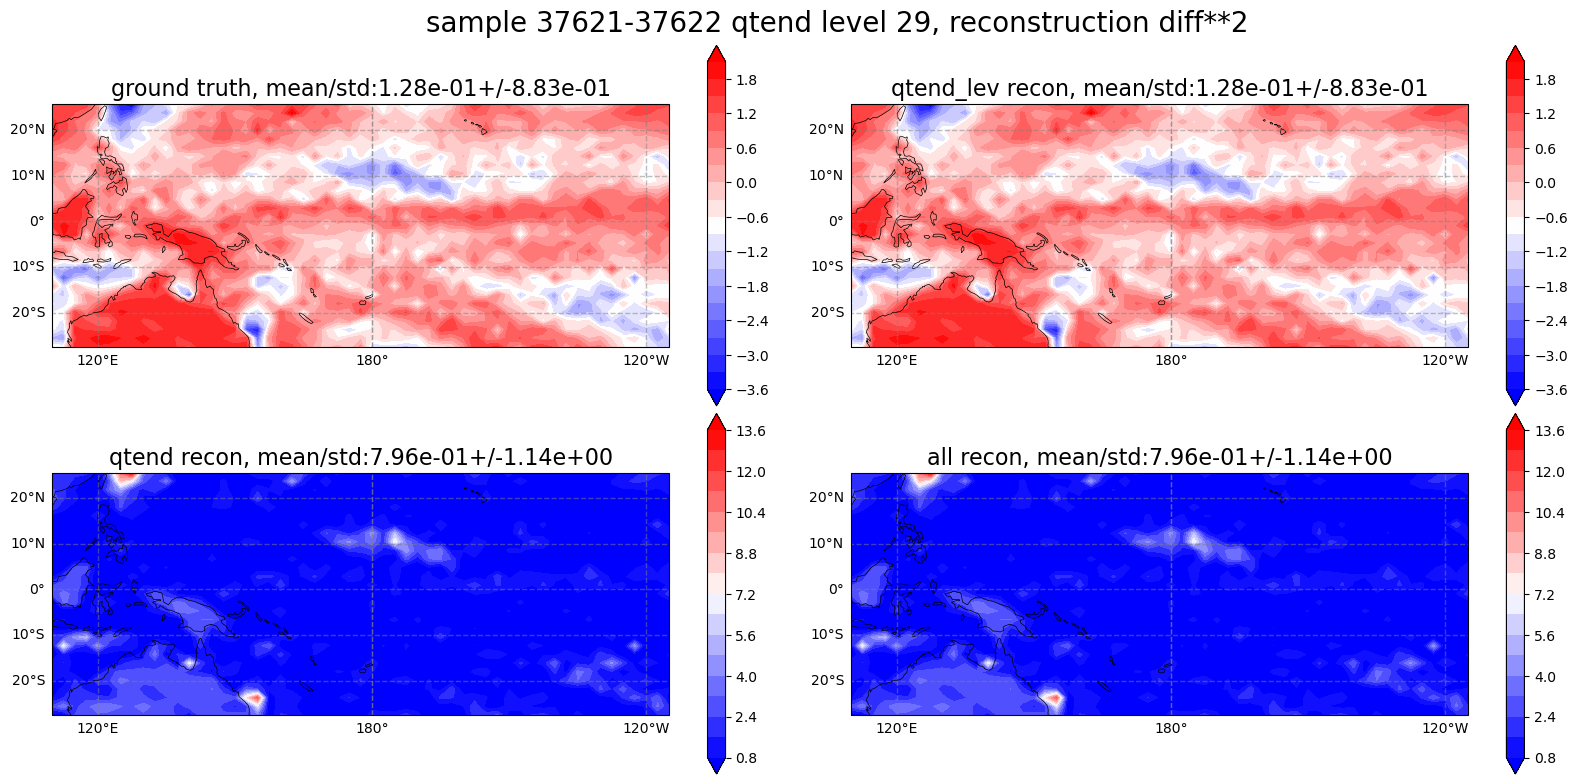

In [142]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction diff**2",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

In [72]:
sample = "37621-37622"
lvl = 29

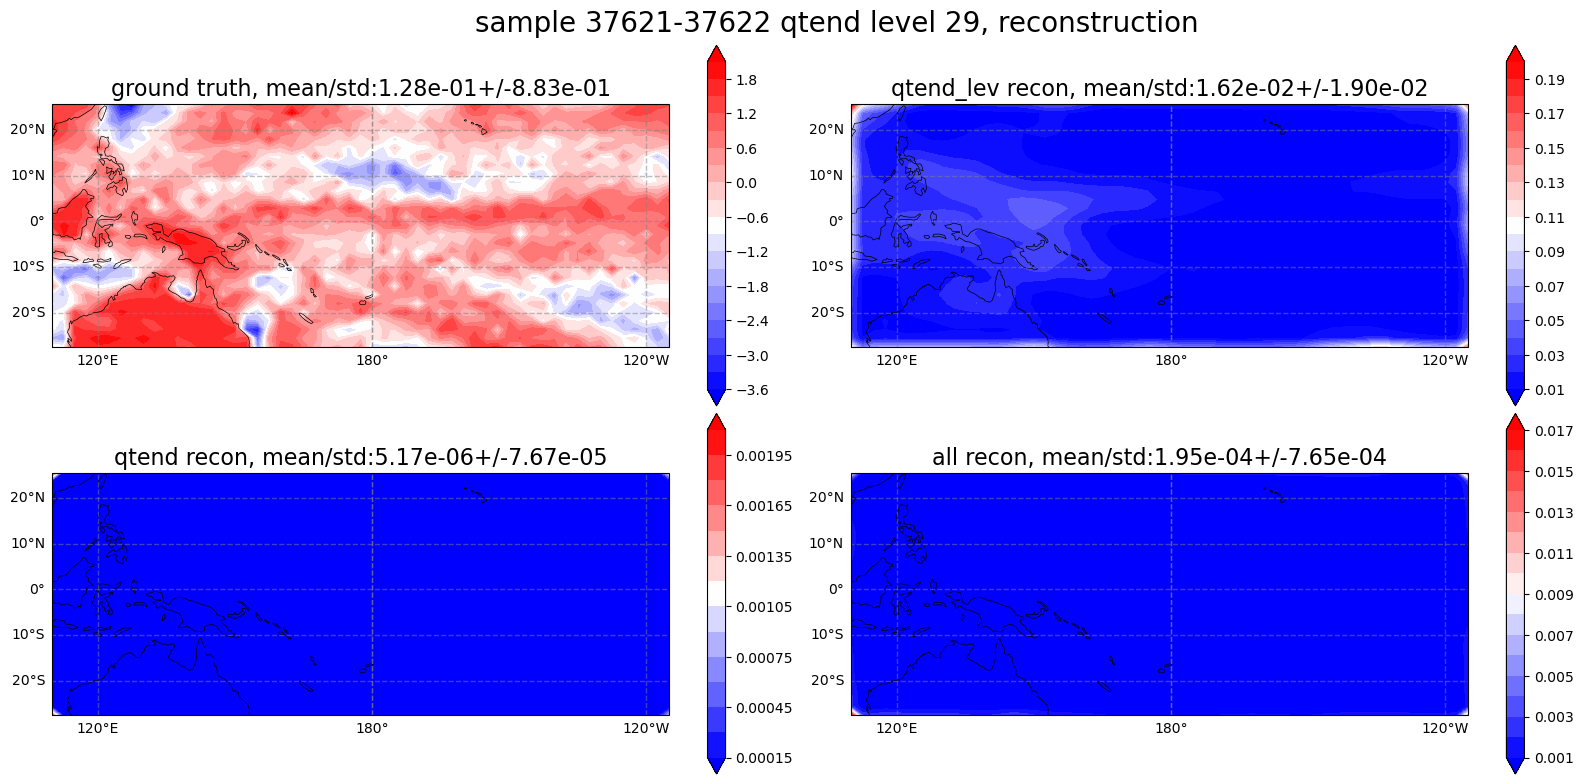

In [143]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

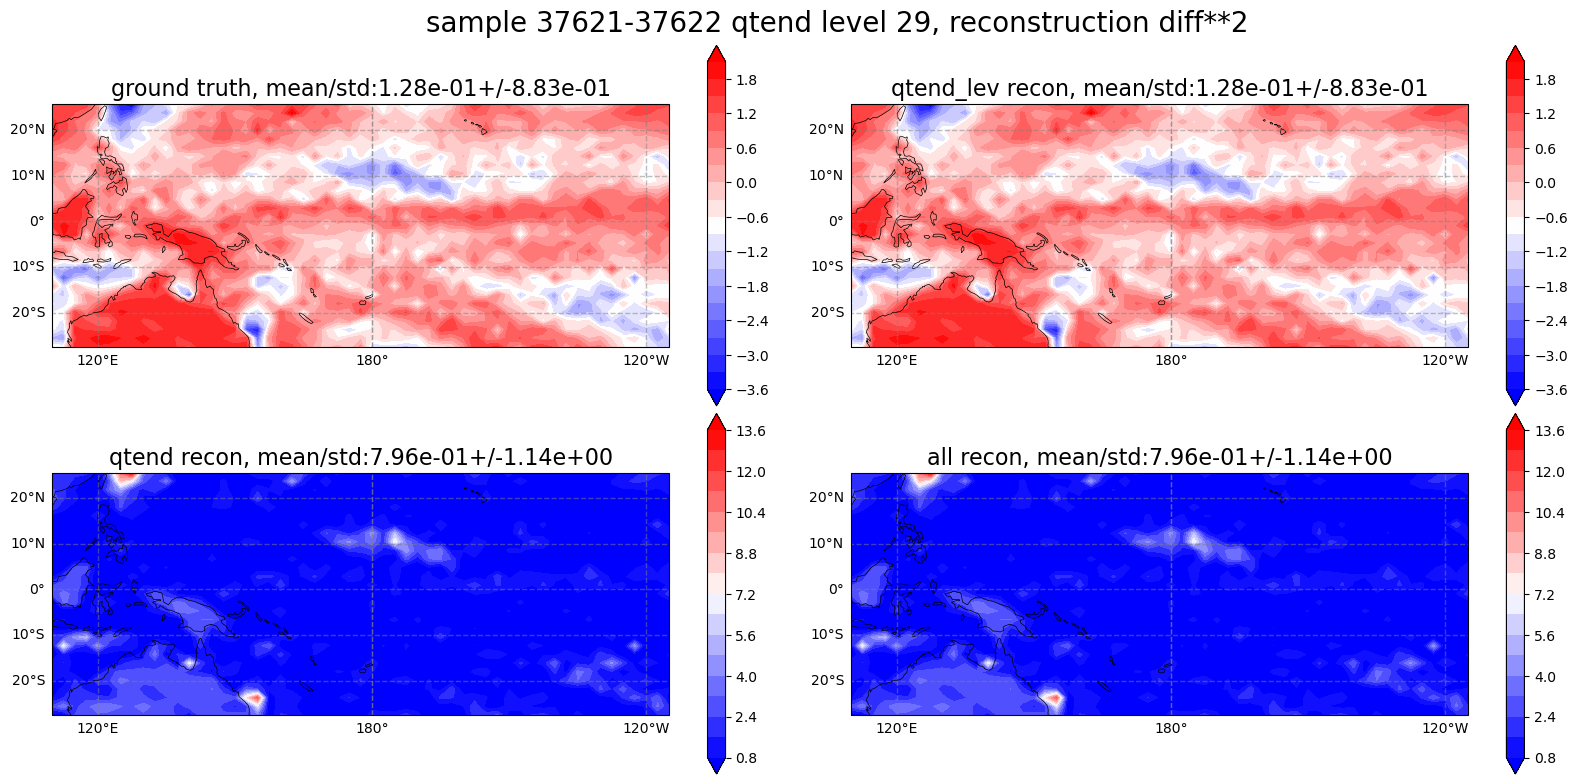

In [144]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = qtend_lev_sample_x - np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")**2
all_sample_x_rec = (qtend_lev_sample_x - np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154])**2
qtend_sample_x_rec = (qtend_lev_sample_x - np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy"))**2
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction diff**2",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

In [123]:
!ls ../offline_test/vae_only

offline_test_ae_0_log_var.npy
offline_test_ae_0_mu.npy
offline_test_ae_0_x.npy
offline_test_ae_0_x_rec.npy
offline_test_ae_0_y.npy
offline_test_ae_0_y_pred.npy
offline_test_ae_1_log_var.npy
offline_test_ae_1_mu.npy
offline_test_ae_1_x.npy
offline_test_ae_1_x_rec.npy
offline_test_ae_1_y.npy
offline_test_ae_1_y_pred.npy
offline_test_ae_2_log_var.npy
offline_test_ae_2_mu.npy
offline_test_ae_2_x.npy
offline_test_ae_2_x_rec.npy
offline_test_ae_2_y.npy
offline_test_ae_2_y_pred.npy
offline_test_ae_36325-36326_log_var.npy
offline_test_ae_36325-36326_mu.npy
offline_test_ae_36325-36326_x.npy
offline_test_ae_36325-36326_x_rec.npy
offline_test_ae_36325-36326_y.npy
offline_test_ae_36325-36326_y_pred.npy
offline_test_ae_36493-36494_log_var.npy
offline_test_ae_36493-36494_mu.npy
offline_test_ae_36493-36494_x.npy
offline_test_ae_36493-36494_x_rec.npy
offline_test_ae_36493-36494_y.npy
offline_test_ae_36493-36494_y_pred.npy
offline_test_ae_36709-36710_log_var.npy
offline_test_ae_36709-36710_mu.npy
offli

In [124]:
!ls ../offline_test/qtend_test

offline_test_ae_0_log_var.npy
offline_test_ae_0_mu.npy
offline_test_ae_0_x.npy
offline_test_ae_0_x_rec.npy
offline_test_ae_0_y.npy
offline_test_ae_0_y_pred.npy
offline_test_ae_1_log_var.npy
offline_test_ae_1_mu.npy
offline_test_ae_1_x.npy
offline_test_ae_1_x_rec.npy
offline_test_ae_1_y.npy
offline_test_ae_1_y_pred.npy
offline_test_ae_2_log_var.npy
offline_test_ae_2_mu.npy
offline_test_ae_2_x.npy
offline_test_ae_2_x_rec.npy
offline_test_ae_2_y.npy
offline_test_ae_2_y_pred.npy
offline_test_ae_37621-37622_log_var.npy
offline_test_ae_37621-37622_mu.npy
offline_test_ae_37621-37622_x.npy
offline_test_ae_37621-37622_x_rec.npy
offline_test_ae_37621-37622_y.npy
offline_test_ae_37621-37622_y_pred.npy
offline_test_ae_39253-39254_log_var.npy
offline_test_ae_39253-39254_mu.npy
offline_test_ae_39253-39254_x.npy
offline_test_ae_39253-39254_x_rec.npy
offline_test_ae_39253-39254_y.npy
offline_test_ae_39253-39254_y_pred.npy
offline_test_ae_3_log_var.npy
offline_test_ae_3_mu.npy
offline_test_ae_3_x.npy
o

In [161]:
sample = "42601-42602"
lvl = 29

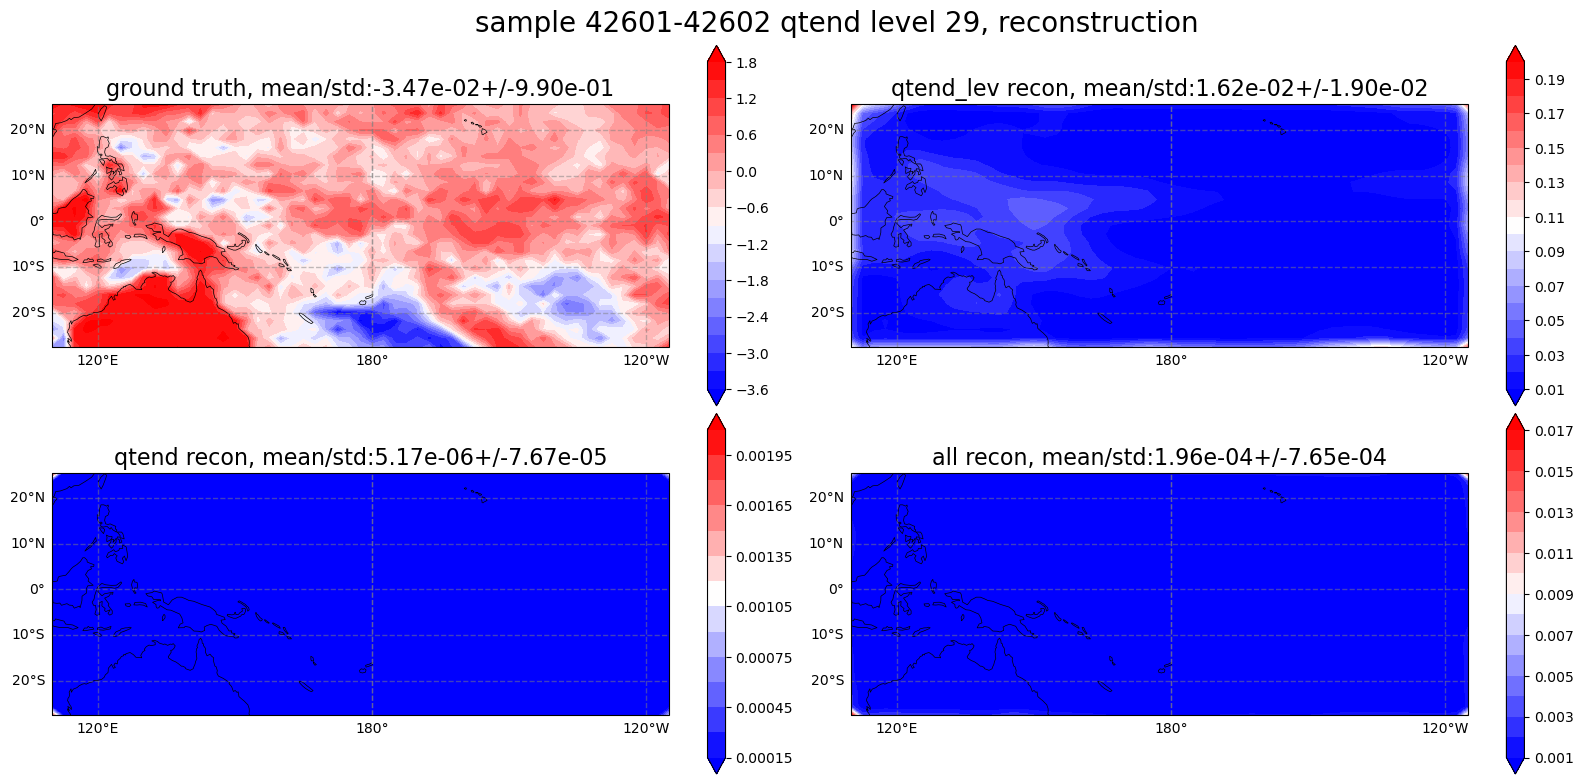

In [162]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

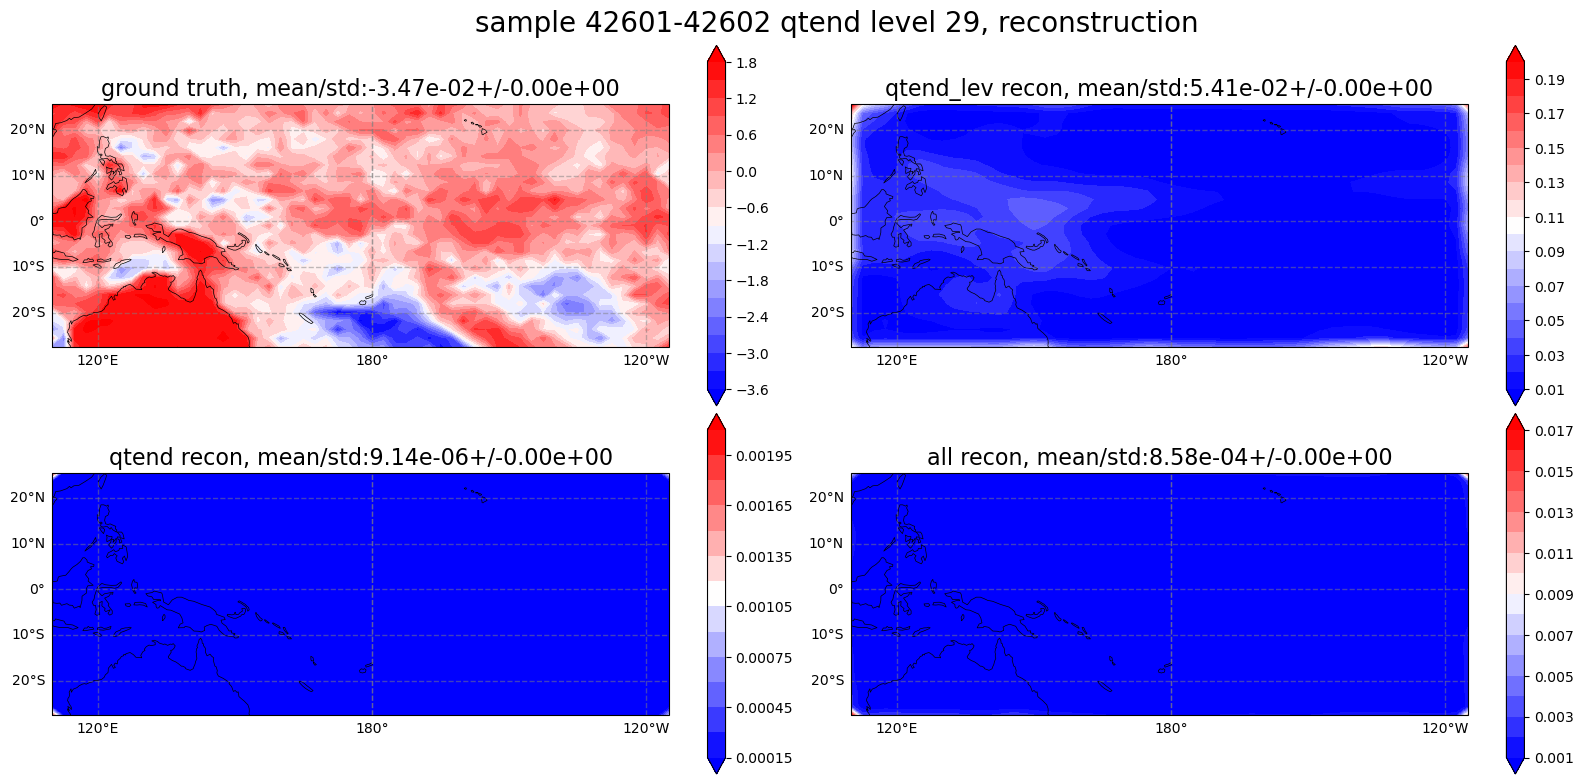

In [164]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")[0,lvl]
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl]
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154][0,lvl]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl]
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x,ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x.mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec,ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec,ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec,ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

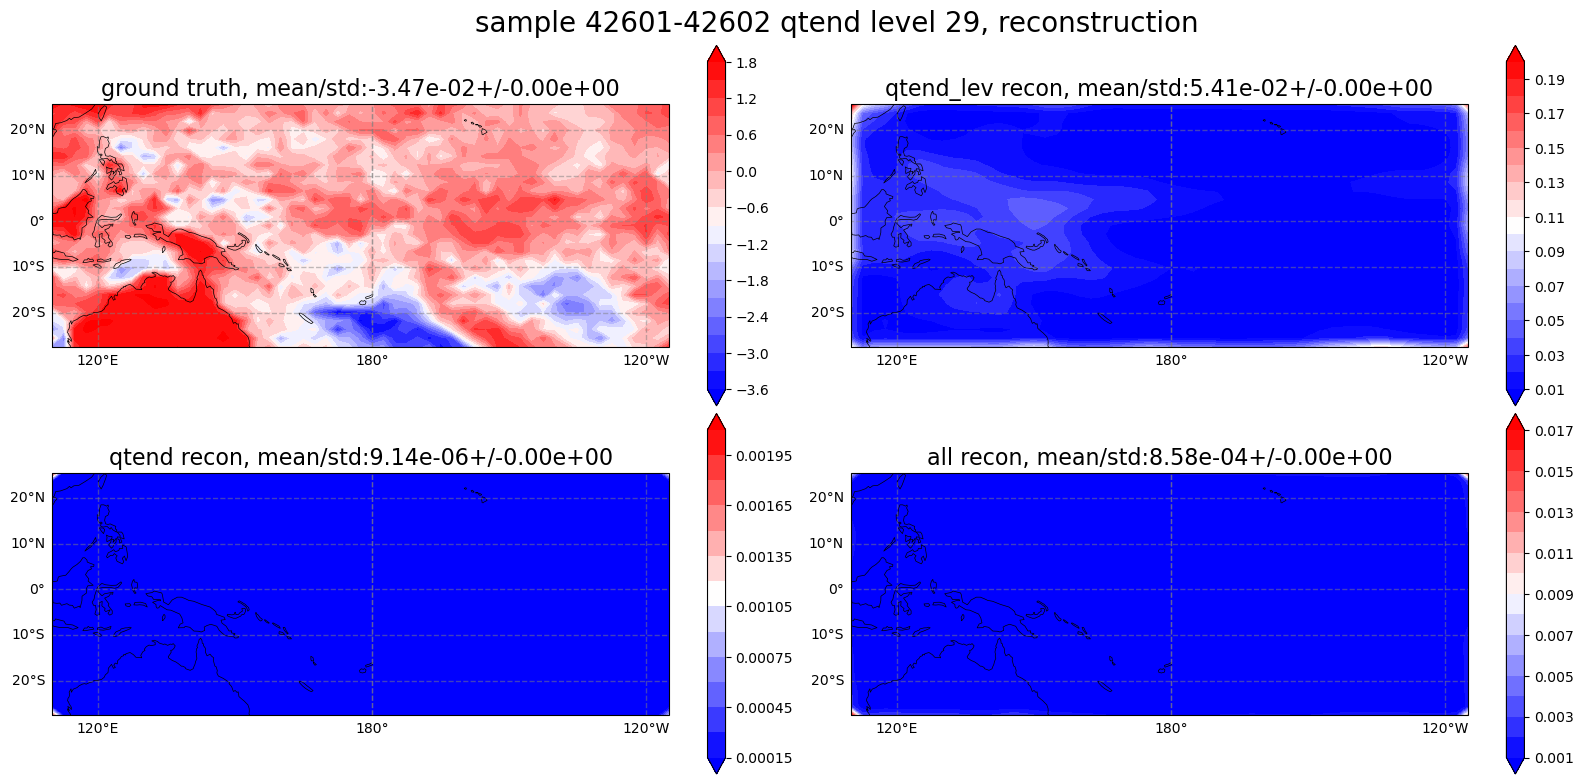

In [167]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")[0,lvl]
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl]
# qtend_lev_sample_x_rec = (qtend_lev_sample_x_rec - qtend_lev_sample_x_rec.mean()) / qtend_lev_sample_x_rec.std()
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154][0,lvl]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")[0,lvl]
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x,ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x.mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec,ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec,ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec,ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

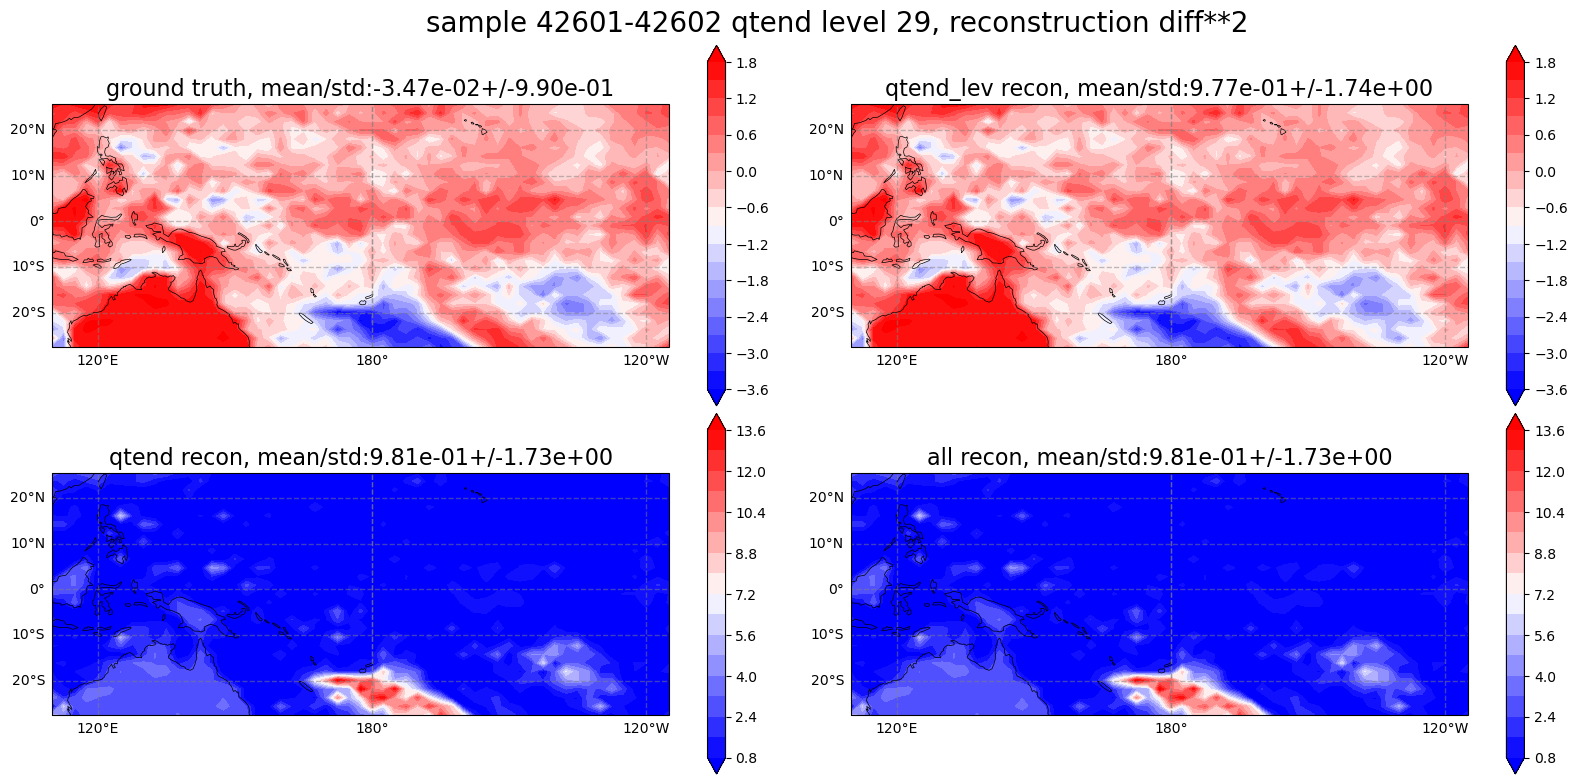

In [163]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = (qtend_lev_sample_x - np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy"))**2
all_sample_x_rec = (qtend_lev_sample_x - np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154])**2
qtend_sample_x_rec = (qtend_lev_sample_x - np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy"))**2
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction diff**2",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

In [148]:
sample = "50666-50667"
lvl = 29

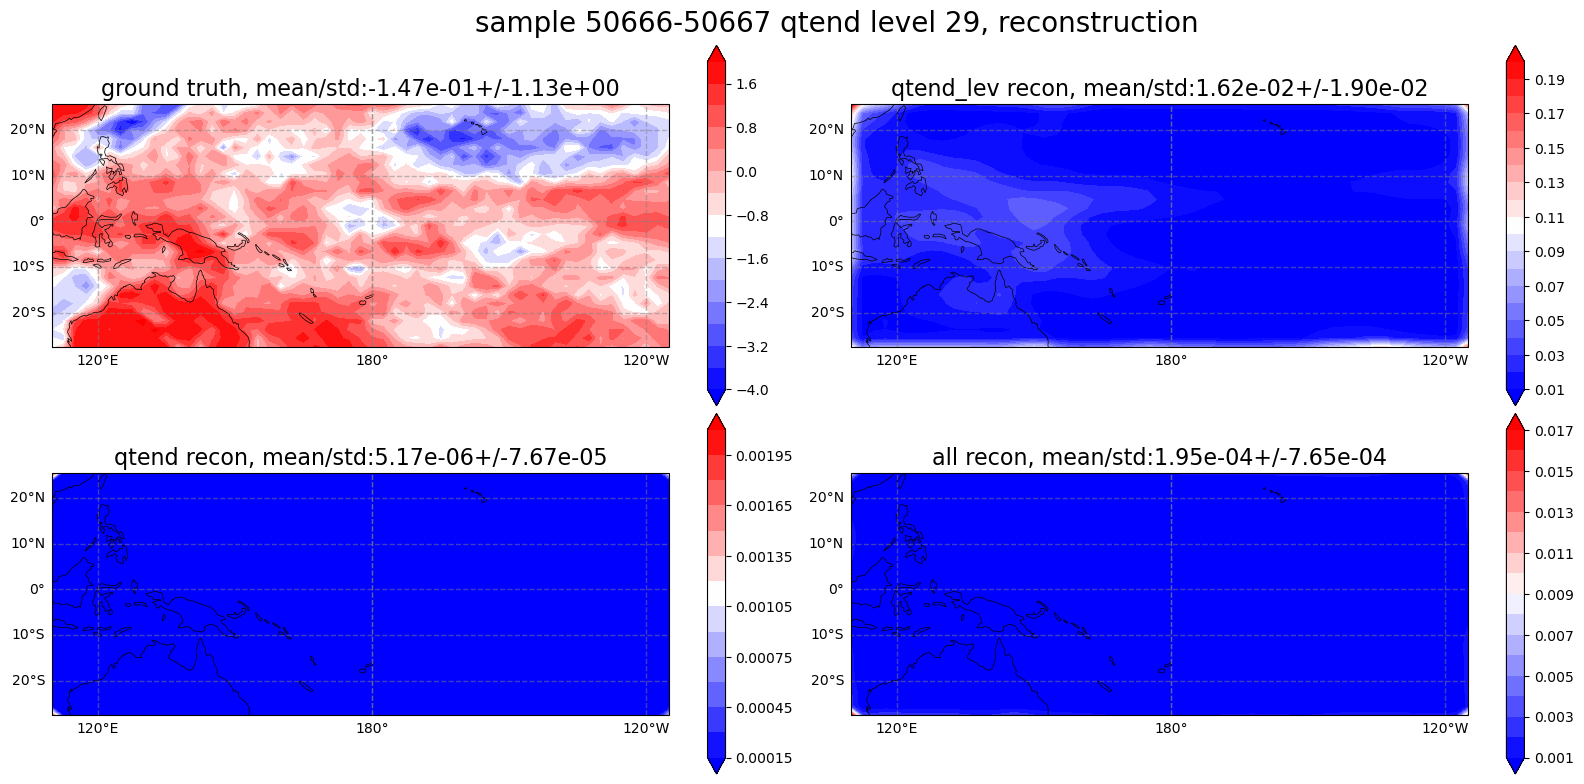

In [149]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")
all_sample_x_rec = np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154]
qtend_sample_x_rec = np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy")
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

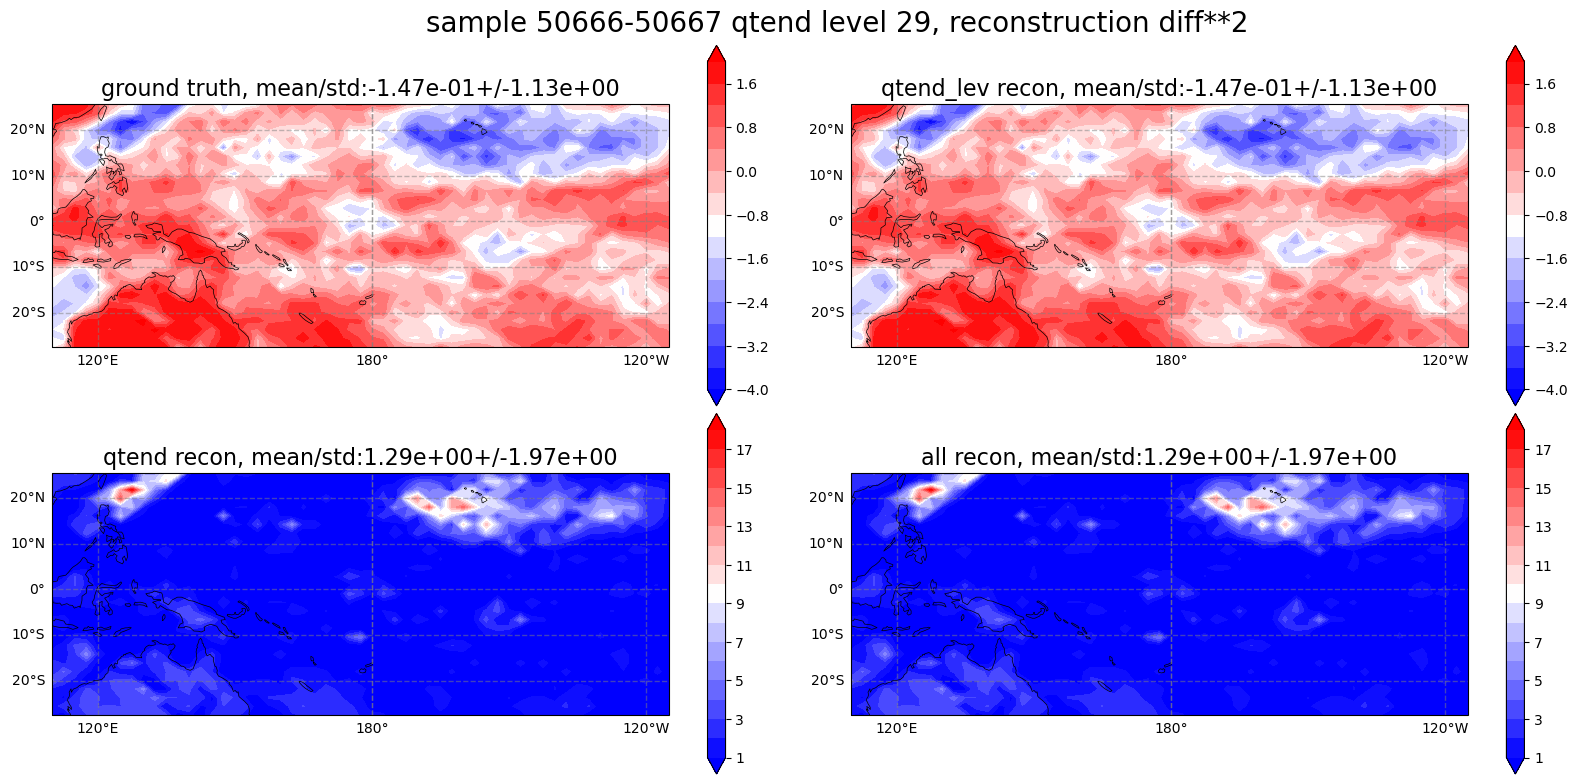

In [150]:
qtend_lev_sample_x = np.load(qtend_lev_test+f"offline_test_ae_{sample}_x.npy")
qtend_lev_sample_x_rec = qtend_lev_sample_x - np.load(qtend_lev_test+f"offline_test_ae_{sample}_x_rec.npy")**2
all_sample_x_rec = (qtend_lev_sample_x - np.load(vae_only+f"offline_test_ae_{sample}_x_rec.npy")[:,124:154])**2
qtend_sample_x_rec = (qtend_lev_sample_x - np.load(qtend_test+f"offline_test_ae_{sample}_x_rec.npy"))**2
fig, ax = plt.subplots(2,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
fig.tight_layout(w_pad=2, h_pad=-40)
fig.suptitle(f"sample {sample} qtend level {lvl}, reconstruction diff**2",y=0.75, fontsize=20)
plot_pacific(qtend_lev_sample_x[0,lvl],ax=ax[0,0])
ax[0,0].set_title(f"ground truth, mean/std:{qtend_lev_sample_x[0,lvl].mean():.2e}+/-{qtend_lev_sample_x[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_lev_sample_x_rec[0,lvl],ax=ax[0,1])
ax[0,1].set_title(f"qtend_lev recon, mean/std:{qtend_lev_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_lev_sample_x_rec[0,lvl].std():.2e}", fontsize=16)
plot_pacific(qtend_sample_x_rec[0,lvl],ax=ax[1,0])
ax[1,0].set_title(f"qtend recon, mean/std:{qtend_sample_x_rec[0,lvl].mean():.2e}+/-{qtend_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plot_pacific(all_sample_x_rec[0,lvl],ax=ax[1,1])
ax[1,1].set_title(f"all recon, mean/std:{all_sample_x_rec[0,lvl].mean():.2e}+/-{all_sample_x_rec[0,lvl].std():.2e}",fontsize=16)
plt.show()

In [151]:
data_path = "../analysis/test_data"

In [152]:
!ls ../analysis/test_data

08689.npy                   08983.npy
08690.npy                   08984.npy
08691.npy                   08985.npy
08692.npy                   08986.npy
08693.npy                   08987.npy
08694.npy                   08988.npy
08695.npy                   08989.npy
08696.npy                   08990.npy
08697.npy                   08991.npy
08698.npy                   08992.npy
08699.npy                   08993.npy
08700.npy                   08994.npy
08701.npy                   08995.npy
08702.npy                   08996.npy
08703.npy                   08997.npy
08704.npy                   08998.npy
08705.npy                   08999.npy
08706.npy                   09000.npy
08707.npy                   09001.npy
08708.npy                   09002.npy
08709.npy                   09003.npy
08710.npy                   09004.npy
08711.npy                   09005.npy
08712.npy                   09006.npy
08713.npy                   09007.npy
08714.npy                   09008.npy
08715.npy   

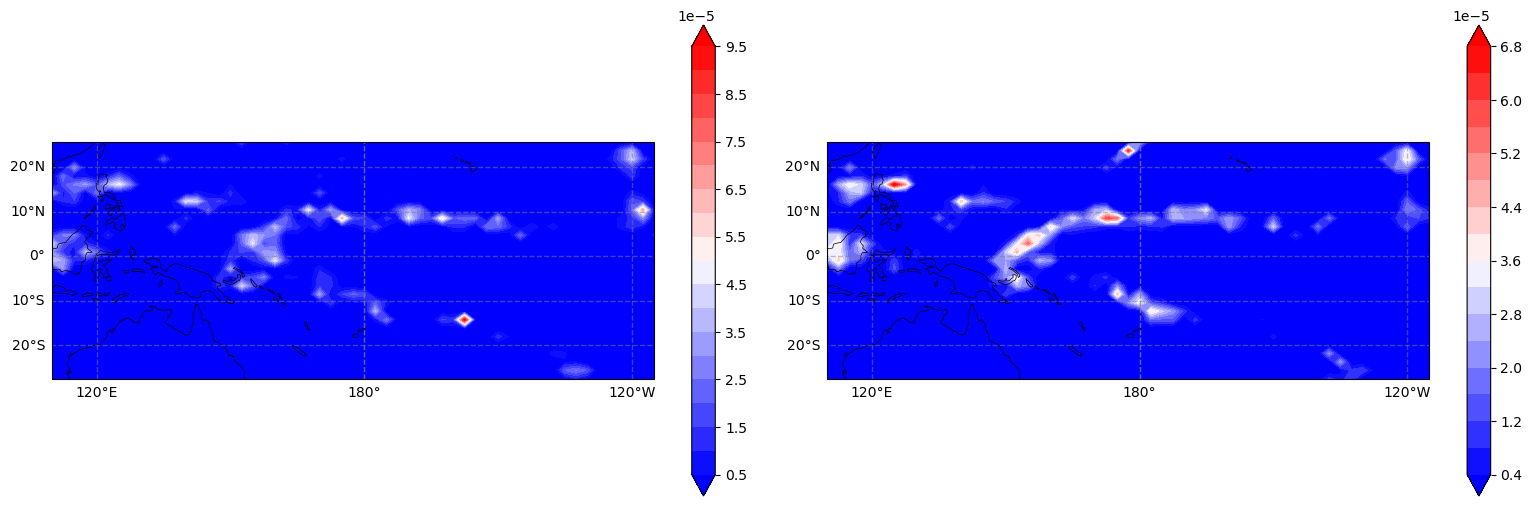

In [158]:
data1 = np.load(data_path + "/08969.npy")
data2 = np.load(data_path + "/08970.npy")
lvl = 124+29
# fig, ax = plt.subplots(1,2)
fig, ax = plt.subplots(1,2, figsize=(16,16), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
plot_pacific(data1[lvl][min_x:max_x,min_y:max_y], ax=ax[0])
plot_pacific(data2[lvl][min_x:max_x,min_y:max_y], ax=ax[1])
plt.tight_layout()
plt.show()